In [1]:
#This example will highlight the find cluster tool by inputting right ascension and declination coordinates of the cluster as well as plot the cluster


In [2]:
#We will start by importing the gaia input module and the mean photometry module. We will query the data and then plot the cluster
import gaiadr3_analysis.gaia_input as gi
import gaiadr3_analysis.mean_photometry as mphot

In [5]:
#This is optional but logging into Gaia Archive using credentials may resolve any access issues when querying
gi.gaia_login_prompt()

INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
Logged in to Gaia archive.


Cluster search near (ra=160.8, dec=-64.4), radius 2.0 deg:
  -> 13786 star(s) found.
  -> grouped into 111 candidate cluster(s).
  -> returning top 10 by member count.


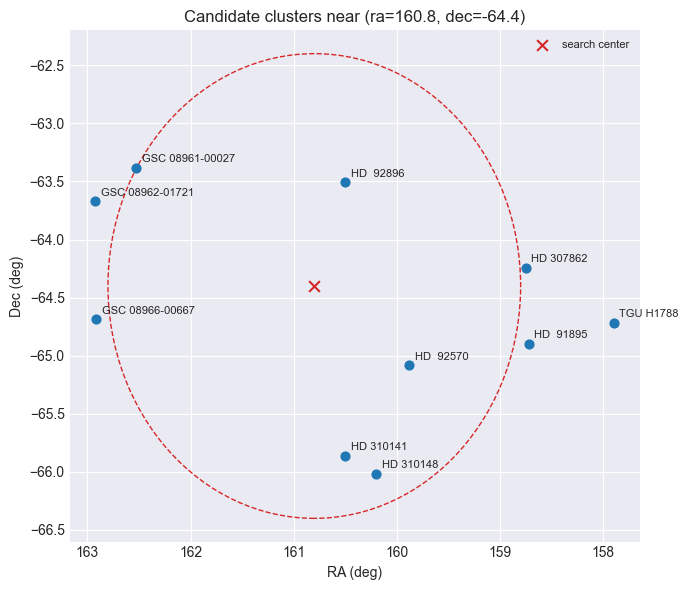

,name,common_name,member_count,ra,dec,otype,separation_deg,implied_distance_pc
0,HD 92570,None,2,159.879755,-65.083434,**,0.788188,150.959347
1,HD 307862,None,2,158.752653,-64.242950,**,0.900911,NaN
2,HD 92896,None,2,160.498714,-63.507271,**,0.902475,NaN
3,GSC 08966-00667,None,2,162.914187,-64.685380,**,0.952462,NaN
4,HD 91895,None,2,158.720420,-64.899421,**,1.020806,149.429925
5,GSC 08962-01721,None,2,162.921371,-63.671255,**,1.180436,NaN
6,GSC 08961-00027,None,2,162.526007,-63.383895,**,1.268525,NaN
7,TGU H1788,None,2,157.897917,-64.718333,DNe,1.286547,NaN
8,HD 310141,None,2,160.501171,-65.863094,**,1.468477,NaN
9,HD 310148,None,2,160.198574,-66.015469,**,1.635016,NaN


In [14]:
#now calling the function and putting the coordinates for the IC 2602 cluster for reference. The function should find the closest cluster which in this case should show IC 2602
gi.find_cluster(ra = 160.8, dec = -64.4, dist_min = 148, dist_max = 154, plot = True)

#Below should be printed the name of the closest cluster found nearby these coordinates

Resolving 'IC 2602', membership_certainty >= 80:
  -> 6229 raw membership link(s) from SIMBAD.
  -> 1673 unique star name(s) after removing duplicates.
  -> 1665 resolved to a Gaia DR3 ID (8 could not be resolved).
  -> 1648 resolved star(s) final, after removing 17 duplicate Gaia ID(s) (same star via a different SIMBAD name).
                              name common_name       gaia_id  \
0            1RXS J095649.1-635934        None  5.249653e+18   
1          2MASS J08092141-4708065        None  5.519273e+18   
2          2MASS J08104428-4727558        None  5.519204e+18   
3          2MASS J08104880-4727223        None  5.519204e+18   
4          2MASS J08111195-6656400        None  5.271426e+18   
...                            ...         ...           ...   
1651  Gaia DR2 5302242954911820928        None           NaN   
1652                     HD  91895        None           NaN   
1653                     HD  92467        None           NaN   
1654                     HD  92

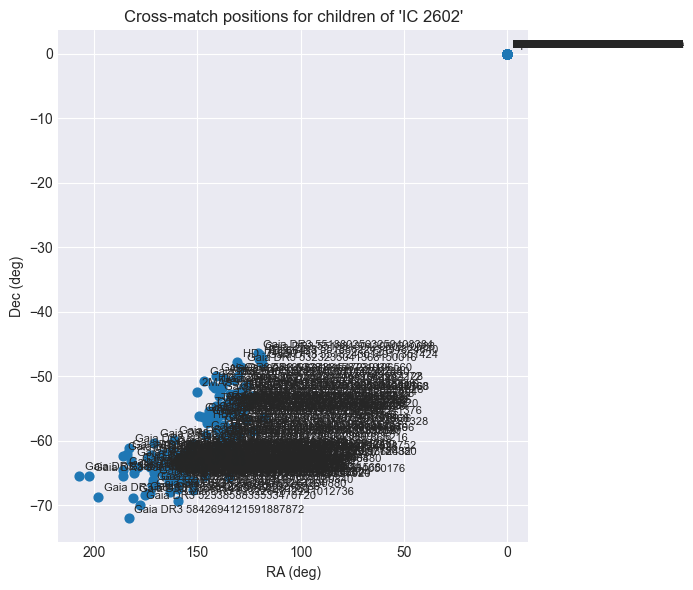

Retrieved 322 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,5852164696354811904,Gaia DR3 5852164696354811904,207.202506,-65.405932,8.393702,-30.469666,-7.345651,16.844038,18.431759,15.628484
1,5239285267016958976,Gaia DR3 5239285267016958976,160.545087,-65.653587,6.737814,-17.545168,10.931354,17.273729,19.288687,15.934874
2,5239679579377629184,Gaia DR3 5239679579377629184,160.022558,-65.320997,0.496446,-6.905009,3.403579,16.540546,16.912392,15.669920
3,5239803789838126080,Gaia DR3 5239803789838126080,161.034409,-64.704993,6.750367,-15.351946,10.239437,14.737613,16.237913,13.538200
4,5250933390113278976,Gaia DR3 5250933390113278976,143.142460,-62.481776,-0.275424,-3.359116,3.216292,19.714674,20.165876,19.117434


In [7]:
#Now our goal is to take the information from the find_cluster and pull actual data for the stars that form the cluster
#We can do this using the resolve ID function, we have the found cluster name and now we use this identifier to query the data for the cluster.

cluster_ID = gi.resolve_id("IC 2602")

id_list = ", ".join(str(s) for s in cluster_ID)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()


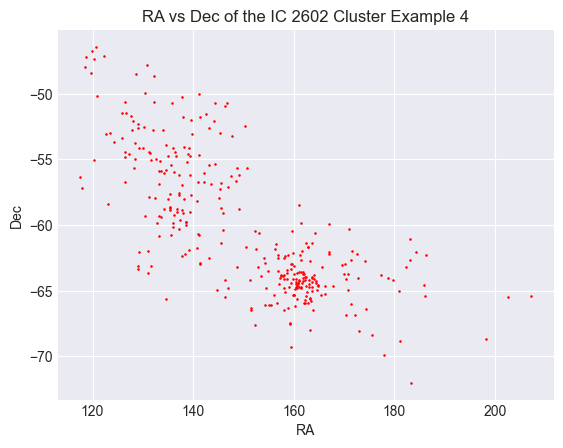

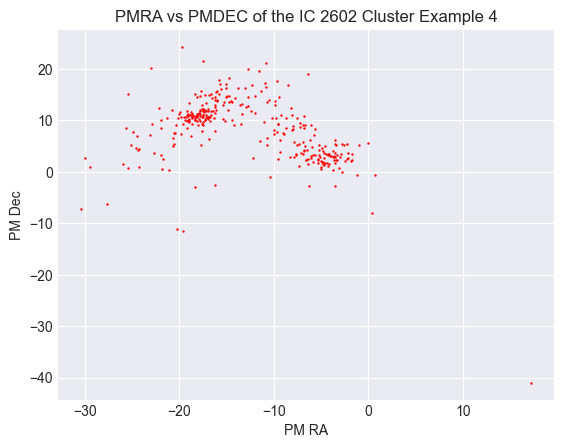

C:\Users\nakia\OneDrive\Documents\GitHub\gaiadr3-analysis\gaiadr3_analysis\mean_photometry.py:210: RuntimeWarning: invalid value encountered in log10
  return phot_g_mean_mag - 5 * np.log10(distance / 10)


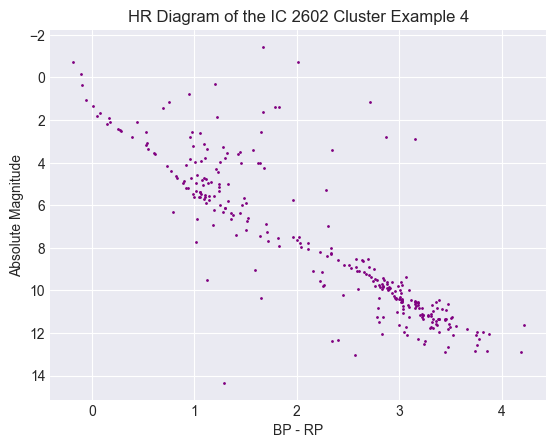

Median: 152.42071369734532, standard deviation: 6398.060335674318
Standard Deviation: 6398.060335674318


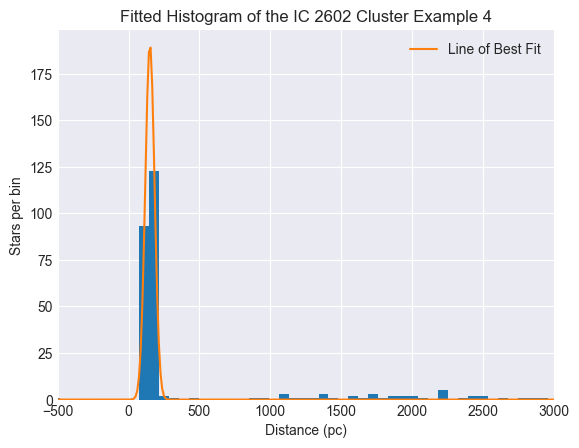

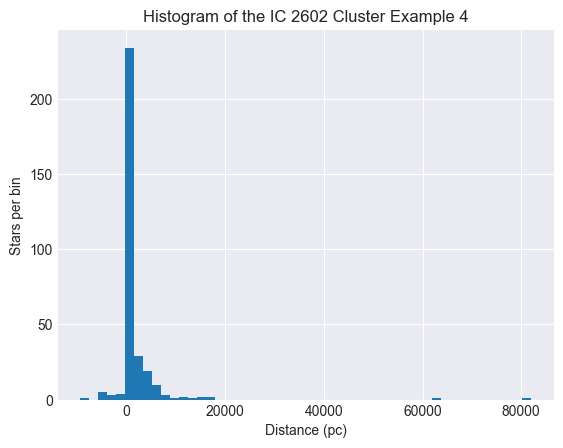

In [8]:
#Now the data will be used to plot simple functions in our mean photometry module. 
#We won't be saving the plots in this example, but if wanted, the save_plot parameter can be set to True and a file_name and save_folder can be given to save the plots with a specific name and in a specific folder.


#Each function, as seen below, is called using the mean_photometry module as mphot. Although is can be imported as any variable. Then the function is written in the form of modname.function_name(parameters)

mphot.ra_vs_dec(df, title = "RA vs Dec of the IC 2602 Cluster Example 4")
mphot.pmra_vs_pmdec(df, title = "PMRA vs PMDEC of the IC 2602 Cluster Example 4")
mphot.plot_hr_diagram(df, title = "HR Diagram of the IC 2602 Cluster Example 4")
mphot.fitted_hist(values=df['parallax'], parallax=True, title = "Fitted Histogram of the IC 2602 Cluster Example 4", bin_num = 1300, range = [-500, 3000])
mphot.hist(values=df['parallax'], parallax=True, title = "Histogram of the IC 2602 Cluster Example 4")
